In [9]:
import tensorflow as tf
import numpy as np
from tensorflow.keras import layers, models
from tensorflow.keras.utils import plot_model

In [10]:
model = models.Sequential([
    layers.Input(shape=(8,)),                           # 8 inputs
    layers.Dense(6, activation='relu', name='H1'),      # Hidden 1: 6 neurons
    layers.Dense(4, activation='sigmoid', name='H2'),   # Hidden 2: 4 neurons
    layers.Dense(3, activation='softmax', name='Output') # Output: 3 neurons
])

In [11]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape          ┃      Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━┩
│ H1 (Dense)                    │ (None, 6)             │           54 │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ H2 (Dense)                    │ (None, 4)             │           28 │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ Output (Dense)                │ (None, 3)             │           15 │
└───────────────────────────────┴───────────────────────┴──────────────┘

 Total params: 97 (388.00 B)

 Trainable params: 97 (388.00 B)

 Non-trainable params: 0 (0.00 B)

In [12]:
x_input = tf.constant([[0.7, 0.4, 0.9, 0.3, 0.6, 0.8, 0.5, 0.2]], dtype=tf.float32)

In [13]:
W1_values = np.array([
    [ 0.2, -0.1,  0.3,  0.4,  0.1, -0.2],
    [ 0.5,  0.3, -0.4,  0.2,  0.6,  0.1],
    [-0.3,  0.2,  0.5,  0.3, -0.1,  0.4],
    [ 0.1, -0.2,  0.4,  0.1,  0.3,  0.2],
    [ 0.4,  0.1,  0.2, -0.3,  0.5,  0.3],
    [-0.2,  0.4,  0.1,  0.5, -0.3,  0.2],
    [ 0.3,  0.2, -0.1,  0.4,  0.2,  0.1],
    [ 0.1, -0.3,  0.2,  0.1,  0.4,  0.5]
])

In [14]:
z_h1 = tf.matmul(x_input, W1_values)

In [15]:
pre_activation_neuron_1 = z_h1[0, 0].numpy()

print(f"The pre-activation value for the first neuron is: {pre_activation_neuron_1:.2f}")

The pre-activation value for the first neuron is: 0.35


In [16]:
logits = tf.constant([[1.2, 0.6, 1.5]], dtype=tf.float32)
probabilities = tf.nn.softmax(logits).numpy()

print(f"Softmax Probabilities: {probabilities}")

Softmax Probabilities: [[0.34498578 0.18933217 0.46568203]]


In [17]:
# True class is 2, so we represent it as a one-hot vector [0, 0, 1]
y_true = tf.constant([[0, 0, 1]], dtype=tf.float32)
cce = tf.keras.losses.CategoricalCrossentropy()
loss = cce(y_true, probabilities).numpy()
print(f"Categorical Cross-Entropy Loss: {loss:.4f}")

Categorical Cross-Entropy Loss: 0.7643


In [18]:
# Check the confidence gap
top_prob = np.max(probabilities)
second_prob = np.sort(probabilities[0])[-2]
gap = top_prob - second_prob

print(f"Confidence Gap: {gap:.4f}")
if gap < 0.2:
    print("Warning: Low confidence gap. Clinical intervention required.")

Confidence Gap: 0.1207


In [19]:
print(f"Top Probability: {top_prob:.4f} (Class 2)")
print(f"Second Probability: {second_prob:.4f} (Class 0)")
print(f"Confidence Gap: {gap:.4f}")

Top Probability: 0.4657 (Class 2)
Second Probability: 0.3450 (Class 0)
Confidence Gap: 0.1207


In [20]:
probs = tf.constant([[0.34, 0.19, 0.47]], dtype=tf.float32)

In [21]:
# Entropy formula: H = -sum(p * log(p))
# We use log base 2 to measure in "bits"
entropy = -tf.reduce_sum(probs * tf.math.log(probs) / tf.math.log(2.0))

print(f"Calculated Entropy: {entropy.numpy():.4f} bits")

Calculated Entropy: 1.4964 bits


In [22]:
# For 3 classes, Max Entropy is log2(3) ≈ 1.58 bits
if entropy > 1.0:
    print("STATUS: HIGH UNCERTAINTY")
    print("Clinical Note: The model is highly undecided; manual triage is critical.")

STATUS: HIGH UNCERTAINTY
Clinical Note: The model is highly undecided; manual triage is critical.


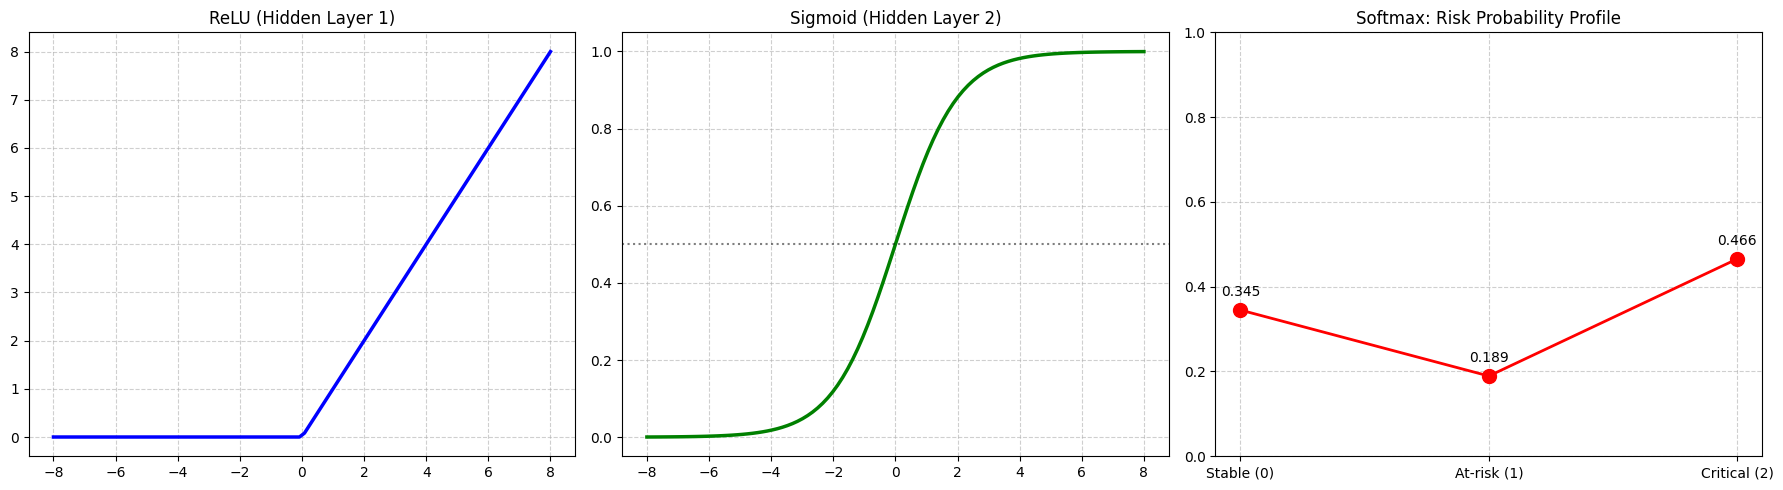

In [39]:
import matplotlib.pyplot as plt

# 1. Define the Activation Functions
def relu(x): return np.maximum(0, x)
def sigmoid(x): return 1 / (1 + np.exp(-x))
def softmax(z):
    e_z = np.exp(z - np.max(z)) # Stability fix
    return e_z / e_z.sum()

# 2. Prepare Data
x_range = np.linspace(-8, 8, 100)
# Data from Case Study Question 3: z = [1.2, 0.6, 1.5]
logits = np.array([1.2, 0.6, 1.5]) 
probs = softmax(logits)
classes = ['Stable (0)', 'At-risk (1)', 'Critical (2)']

# 3. Create Integrated "Ax Plot"
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: ReLU (Hidden Layer 1)
axes[0].plot(x_range, relu(x_range), color='blue', lw=2.5)
axes[0].set_title("ReLU (Hidden Layer 1)")
axes[0].grid(True, linestyle='--', alpha=0.6)

# Plot 2: Sigmoid (Hidden Layer 2)
axes[1].plot(x_range, sigmoid(x_range), color='green', lw=2.5)
axes[1].axhline(0.5, color='black', linestyle=':', alpha=0.5)
axes[1].set_title("Sigmoid (Hidden Layer 2)")
axes[1].grid(True, linestyle='--', alpha=0.6)

# Plot 3: Softmax "Profile" (Output Layer)
# Using markers ('o') and lines ('-') for the 3 discrete classes
axes[2].plot(classes, probs, marker='o', markersize=10, linestyle='-', color='red', lw=2)
axes[2].set_title("Softmax: Risk Probability Profile")
axes[2].set_ylim(0, 1.0)
axes[2].grid(True, linestyle='--', alpha=0.6)

# Labeling the Softmax points
for i, val in enumerate(probs):
    axes[2].annotate(f"{val:.3f}", (classes[i], probs[i]), textcoords="offset points", xytext=(0,10), ha='center')

plt.tight_layout() # Ensures everything fits without clipping
plt.show()